# Description

It explores the context/tissue/cell type of the top samples associated with an LV.

Follow the notebook instructions below.

# Modules

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.recount2 import LVAnalysis
from utils import chunker
import conf

# Settings

Specify below the LV id you are interested in:

In [2]:
LV_NAME = "LV683"

# Paths

These are paths to folder and files where we'll save our figures.

In [3]:
OUTPUT_FIGURES_DIR = Path(conf.RESULTS_DIR, "demo", f"{LV_NAME.lower()}").resolve()
display(OUTPUT_FIGURES_DIR)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PosixPath('/opt/data/results/demo/lv683')

In [4]:
OUTPUT_CELL_TYPE_FILEPATH = OUTPUT_FIGURES_DIR / f"{LV_NAME.lower()}-cell_types.svg"
display(OUTPUT_CELL_TYPE_FILEPATH)

PosixPath('/opt/data/results/demo/lv683/lv683-cell_types.svg')

# Load MultiPLIER summary

In [5]:
multiplier_model_summary = pd.read_pickle(conf.MULTIPLIER["MODEL_SUMMARY_FILE"])

In [6]:
multiplier_model_summary.shape

(2157, 5)

In [7]:
multiplier_model_summary.head()

,pathway,LV index,AUC,p-value,FDR
1,KEGG_LYSINE_DEGRADATION,1,0.388059,0.866078,0.956005
2,REACTOME_MRNA_SPLICING,1,0.733057,0.000048,0.000582
3,MIPS_NOP56P_ASSOCIATED_PRE_RRNA_COMPLEX,1,0.680555,0.001628,0.011366
4,KEGG_DNA_REPLICATION,1,0.549473,0.312155,0.539951
5,PID_MYC_ACTIVPATHWAY,1,0.639303,0.021702,0.083739


# Load LV data

You can use the `LVAnalysis` class to explore an LV.

In [8]:
lv_obj = LVAnalysis(LV_NAME)

Here I show the top 20 genes for our LV. You can see gene symbols, the LV weight (in column `LV603`) and the cytoband.

In [9]:
lv_obj.lv_genes.head(20)

,gene_name,LV683,gene_band
0,GTF2F1,5.986470,19p13.3
1,RACGAP1,3.695124,12q13.12
2,DYRK3,3.608951,1q32.1
3,STX18,3.600777,4p16.2
4,ARRB1,3.335755,11q13.4
5,ARF3,3.296877,12q13.12
6,SIRT7,3.116649,17q25.3
7,NRF1,2.582195,7q32.2
8,KIF18A,2.367854,11p14.1
9,ATG4A,2.290316,NaN


Show the pathways our LV is aligned to (neutrophils):

In [10]:
multiplier_model_summary[
    multiplier_model_summary["LV index"].isin((LV_NAME[2:],))
    & (
        (multiplier_model_summary["FDR"] < 0.05)
        & (multiplier_model_summary["AUC"] >= 0.75)
    )
]

[2025-09-24 16:27:21,527 - numexpr.utils] INFO: Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
[2025-09-24 16:27:21,528 - numexpr.utils] INFO: NumExpr defaulting to 8 threads.


,pathway,LV index,AUC,p-value,FDR


Here I load the LV metadata.
This is, for each sample from our matrix B, we load its metadata.
The `LVAnalysis` class takes care of downloading all necessary files from recount2.

In [11]:
lv_data = lv_obj.get_experiments_data()

SRP030617, SRP055569, SRP057196, SRP042161, SRP060416, SRP066834, SRP050499, SRP064464, SRP020646, SRP055153, SRP026620, SRP018719, SRP004837, SRP012461, SRP013363, SRP059379, SRP018853, SRP002487, SRP022892, SRP041494, SRP052612, SRP058773, SRP014670, SRP018525, SRP002326, SRP044042, SRP026537, SRP015449, SRP057205, SRP026454, SRP063840, SRP009266, SRP040442, SRP064259, SRP018838, SRP059775, SRP045659, SRP036790, SRP017933, SRP045573, SRP025982, SRP064323, SRP004042, SRP033135, SRP032833, SRP017777, SRP061241, SRP041753, SRP028301, SRP061243, SRP022591, SRP035391, SRP034666, SRP008145, SRP001758, SRP041162, 

/opt/code/libs/data/recount2.py:323: UserWarning: Not all experiments data could be loaded (55 != 56)
  warnings.warn(


In [12]:
lv_data.shape

(7637, 95)

In [13]:
lv_data.head()

cdna synthesis method library construction method  \
project   run                                                            
SRP030617 SRR1003755        Superscript RT        Nextera (transposon)   
          SRR1003756        Superscript RT        Nextera (transposon)   
          SRR1003757      Clontech SMARTer        Nextera (transposon)   
          SRR1003758      Clontech SMARTer        Nextera (transposon)   
          SRR1003759      Clontech SMARTer        Nextera (transposon)   

                     cell line cell type tissue  age c1 chip id  \
project   run                                                     
SRP030617 SRR1003755    HCT116       NaN    NaN  NaN        NaN   
          SRR1003756    HCT116       NaN    NaN  NaN        NaN   
          SRR1003757    HCT116       NaN    NaN  NaN        NaN   
          SRR1003758    HCT116       NaN    NaN  NaN        NaN   
          SRR1003759    HCT116       NaN    NaN  NaN        NaN   

                     experiment_sample_name patient id subtype  ... origin  \
project   run                                                   ...          
SRP030617 SRR1003755                    NaN        NaN     NaN  ...    NaN   
          SRR1003756                    NaN        NaN     NaN  ...    NaN   
          SRR1003757                    NaN        NaN     NaN  ...    NaN   
          SRR1003758                    NaN        NaN     NaN  ...    NaN   
          SRR1003759                    NaN        NaN     NaN  ...    NaN   

                     antibodies parental cell line library prep protocol  \
project   run                                                              
SRP030617 SRR1003755        NaN                NaN                   NaN   
          SRR1003756        NaN                NaN                   NaN   
          SRR1003757        NaN                NaN                   NaN   
          SRR1003758        NaN                NaN                   NaN   
          SRR1003759        NaN                NaN                   NaN   

                     sirna cell line stably expresses reporter clip antibody  \
project   run                                                                  
SRP030617 SRR1003755   NaN                        NaN      NaN           NaN   
          SRR1003756   NaN                        NaN      NaN           NaN   
          SRR1003757   NaN                        NaN      NaN           NaN   
          SRR1003758   NaN                        NaN      NaN           NaN   
          SRR1003759   NaN                        NaN      NaN           NaN   

                     library source     LV683  
project   run                                  
SRP030617 SRR1003755            NaN  0.062616  
          SRR1003756            NaN  0.061524  
          SRR1003757            NaN  0.050596  
          SRR1003758            NaN  0.056151  
          SRR1003759            NaN  0.048748  

[5 rows x 95 columns]

# LV cell types analysis

## Get top attributes

Here I quickly show the top attributes in our metadata for which we have the largest LV variance.
This is just to have an idea of the variance across different attributes

In [14]:
lv_attrs = lv_obj.get_attributes_variation_score()
display(lv_attrs.head(20))

cdna synthesis method          0.630954
library construction method    0.630954
cell line                      0.067114
transduction                   0.018071
cell marker                    0.011986
cell line stably expressing    0.005525
donor                          0.005496
reprogramming vector           0.005395
iPSc                           0.005395
genotype                       0.005192
disease state                  0.004933
age                            0.004856
time                           0.004818
experiment_sample_name         0.004810
c1 chip id                     0.004810
tissue                         0.004116
culture medium                 0.004065
facs gating                    0.003839
tonsil donor                   0.003839
Stage                          0.003696
dtype: float64

Since we are interested in cell types and tissues, the code below will find which attributes contain "cell type" or "tissue", so we can select from these results.

In [15]:
# show those with cell type or tissue in their name
_tmp = pd.Series(lv_attrs.index)
lv_attrs[
    _tmp.str.match(
        "(?:cell.*(type|line)$)|(?:tissue$)|(?:tissue.*type$)",
        case=False,
        flags=re.IGNORECASE,
    ).values
].sort_values(ascending=False)

cell line      0.067114
tissue         0.004116
cell type      0.003199
tissue type    0.000275
dtype: float64

Select from the output above those you are interested in. Usually all of them.

In [17]:
lv_attrs_selected = [
    "cell line",
    "tissue",
    "cell type",
    "tissue type",
]

In [18]:
_tmp = lv_data.loc[
    :,
    lv_attrs_selected + [LV_NAME],
]

In [19]:
_tmp_seq = list(chunker(_tmp.sort_values(LV_NAME, ascending=False), 25))

Now that we selected attributes that might be providing information about the cell type, we can see which are the top ones.

If you change the number in the cell below, you can paginate over the entire set of results; for example, with `_tmp_seq[1]` you'll see the next "page" in a descending order with respect to the LV value. So the ones at the top are the most important ones.

In [20]:
_tmp_seq[0]

cell line  \
project   run                    
SRP030617 SRR1003771    HCT116   
          SRR1003767    HCT116   
          SRR1003770    HCT116   
SRP055569 SRR2019120       NaN   
SRP057196 SRR1974794       NaN   
SRP055569 SRR1821508       NaN   
SRP057196 SRR1974755       NaN   
SRP042161 SRR1295299      CSC8   
SRP060416 SRR2088176       NaN   
SRP030617 SRR1003765    HCT116   
          SRR1003768    HCT116   
SRP066834 SRR2967710       NaN   
SRP030617 SRR1003769    HCT116   
          SRR1003766    HCT116   
SRP055569 SRR2019093       NaN   
SRP066834 SRR2967586       NaN   
SRP042161 SRR1295113       NaN   
SRP057196 SRR1974734       NaN   
SRP055569 SRR1821652       NaN   
SRP060416 SRR2088266       NaN   
SRP055569 SRR1821710       NaN   
SRP066834 SRR2967301       NaN   
          SRR2967759       NaN   
SRP050499 SRR2013757       NaN   
SRP042161 SRR1294921       NaN   

                                                                 tissue  \
project   run                                                             
SRP030617 SRR1003771                                                NaN   
          SRR1003767                                                NaN   
          SRR1003770                                                NaN   
SRP055569 SRR2019120                                                NaN   
SRP057196 SRR1974794                                        hippocampus   
SRP055569 SRR1821508                                                NaN   
SRP057196 SRR1974755                                             cortex   
SRP042161 SRR1295299                                                NaN   
SRP060416 SRR2088176                                                NaN   
SRP030617 SRR1003765                                                NaN   
          SRR1003768                                                NaN   
SRP066834 SRR2967710                                    Fetal neocortex   
SRP030617 SRR1003769                                                NaN   
          SRR1003766                                                NaN   
SRP055569 SRR2019093                                                NaN   
SRP066834 SRR2967586  Microdissected cortical-like ventricle from ce...   
SRP042161 SRR1295113                                                NaN   
SRP057196 SRR1974734                                             cortex   
SRP055569 SRR1821652                                                NaN   
SRP060416 SRR2088266                                                NaN   
SRP055569 SRR1821710                                                NaN   
SRP066834 SRR2967301                Dissociated whole cerebral organoid   
          SRR2967759                                    Fetal neocortex   
SRP050499 SRR2013757                                                NaN   
SRP042161 SRR1294921                                                NaN   

                                                              cell type  \
project   run                                                             
SRP030617 SRR1003771                                                NaN   
          SRR1003767                                                NaN   
          SRR1003770                                                NaN   
SRP055569 SRR2019120  mixture of U87 human glioma cells and WI-38 hu...   
SRP057196 SRR1974794                                        endothelial   
SRP055569 SRR1821508  mixture of U87 human glioma cells and MCF10a h...   
SRP057196 SRR1974755                                        endothelial   
SRP042161 SRR1295299                             Gliomasphere Cell Line   
SRP060416 SRR2088176                       tonsil Innate lymphoid cells   
SRP030617 SRR1003765                                                NaN   
          SRR1003768                                                NaN   
SRP066834 SRR2967710                                                NaN   
SRP030617 SRR1003769      

You can see above that the RNA-seq samples are from neutrophils or granulocytes.
If we move to the next "page", we'll see this:

In [21]:
_tmp_seq[1]

,,cell line,tissue,cell type,tissue type,LV683
project,run,,,,,
SRP055569,SRR2019226,NaN,NaN,mixture of U87 human glioma cells and WI-38 hu...,NaN,0.284343
SRP066834,SRR2967662,NaN,Fetal neocortex,NaN,NaN,0.263965
SRP064464,SRR2558130,NaN,NaN,NaN,NaN,0.247437
SRP055569,SRR1821625,NaN,NaN,MCF10a human breast cancer cells,NaN,0.243034
SRP066834,SRR2967805,NaN,Fetal neocortex,NaN,NaN,0.237884
SRP042161,SRR1295284,CSC8,NaN,Gliomasphere Cell Line,NaN,0.237094
SRP055569,SRR1821388,NaN,NaN,U87 human glioma cells,NaN,0.232234
SRP060416,SRR2088522,NaN,NaN,tonsil Innate lymphoid cells,NaN,0.231192
SRP020646,SRR823339,54-1,NaN,NaN,NaN,0.230796


Although the attributes we selected (`cell type`, `celltype` and `tissue`) seem to be enough for most of the RNA-seq samples to get their cell types, this is not the case for some of them. For example, we have empty values (NaN) for `SRP015360`.

You can explore the metadata provided for a particular SPR with the code below. Let's see what we have in `SRP015360`:

In [22]:
# list the top 10 samples from this project
lv_data.loc[["SRP035864"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(10)

KeyError: "['SRP035864'] not in index"

So for `SRP015360` we only have three attributes: `age`, `Sex` and `treatment`. No cell type information. Here you can start grasping the challenges in analyzing this data.

If you are really interested in this metadata for this project, you can use this URL:
```
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP015360
```
where you can put the SRP code you want. If you check the URL above, you'll see that these samples were taken from neutrophils as well (treated with different stimuli), although we don't have metadata about the cell type/tissue.

Ok, we do not want several attributes conveying the same information (cell types), just a single one, so here we'll combine the attributes we found before with a particular _order_.
In this case I select `cell type` _first_ (the order is important), `celltype` as second, and `tissue` as third/last.
This means that I will use the information in `cell type` first, but if this is empty (as in `SRP045500`), we'll try with `celltype`, and so on.

In [23]:
SELECTED_ATTRIBUTES = [
    "cell line",
    "tissue",
    "cell type",
    "tissue type",
]

## Get a single attribute with "cell type/tissue" information

In [24]:
plot_data = lv_data.loc[:, SELECTED_ATTRIBUTES + [LV_NAME]]

In [25]:
# if blank/nan, fill cell type column with tissue content
_new_column = plot_data[SELECTED_ATTRIBUTES].fillna(method="backfill", axis=1)[
    SELECTED_ATTRIBUTES[0]
]
plot_data[SELECTED_ATTRIBUTES[0]] = _new_column
plot_data = plot_data.drop(columns=SELECTED_ATTRIBUTES[1:])
plot_data = plot_data.fillna({SELECTED_ATTRIBUTES[0]: "NOT CATEGORIZED"})

In [26]:
plot_data = plot_data.sort_values(LV_NAME, ascending=False)

In [27]:
plot_data.head(20)

cell line  \
project   run                                                             
SRP030617 SRR1003771                                             HCT116   
          SRR1003767                                             HCT116   
          SRR1003770                                             HCT116   
SRP055569 SRR2019120  mixture of U87 human glioma cells and WI-38 hu...   
SRP057196 SRR1974794                                        hippocampus   
SRP055569 SRR1821508  mixture of U87 human glioma cells and MCF10a h...   
SRP057196 SRR1974755                                             cortex   
SRP042161 SRR1295299                                               CSC8   
SRP060416 SRR2088176                       tonsil Innate lymphoid cells   
SRP030617 SRR1003765                                             HCT116   
          SRR1003768                                             HCT116   
SRP066834 SRR2967710                                    Fetal neocortex   
SRP030617 SRR1003769                                             HCT116   
          SRR1003766                                             HCT116   
SRP055569 SRR2019093                  WI-38 human lung fibroblast cells   
SRP066834 SRR2967586  Microdissected cortical-like ventricle from ce...   
SRP042161 SRR1295113                                       Glioblastoma   
SRP057196 SRR1974734                                             cortex   
SRP055569 SRR1821652                   MCF10a human breast cancer cells   
SRP060416 SRR2088266                       tonsil Innate lymphoid cells   

                         LV683  
project   run                   
SRP030617 SRR1003771  6.038998  
          SRR1003767  5.903295  
          SRR1003770  0.880135  
SRP055569 SRR2019120  0.850227  
SRP057196 SRR1974794  0.701954  
SRP055569 SRR1821508  0.680209  
SRP057196 SRR1974755  0.617198  
SRP042161 SRR1295299  0.538803  
SRP060416 SRR2088176  0.424161  
SRP030617 SRR1003765  0.420872  
          SRR1003768  0.403831  
SRP066834 SRR2967710  0.386389  
SRP030617 SRR1003769  0.375881  
          SRR1003766  0.374505  
SRP055569 SRR2019093  0.363062  
SRP066834 SRR2967586  0.348710  
SRP042161 SRR1295113  0.343379  
SRP057196 SRR1974734  0.334211  
SRP055569 SRR1821652  0.326022  
SRP060416 SRR2088266  0.325603

You can see that now all attributes ("celltype", "cell type" and "tissue") are combined under a single attribute named "cell type".
For example, if you look at `SRP045500`, which had a value under "celltype" but an empty (NaN) value for attribute "cell type", that now the value was moved to "cell type" (it was unified into this single attribute).

If you see "NOT CATEGORIZED", it means that none of the attributes you used had a value (they were all empty or NaN). In this case you would go the URL before and read the article/RNA-seq data description to find out the cell type or tissue (or whatever attribute your are interested in).

## Standardize cell type names

When cell type values are different but represent the same cell type, we unify them:

In [28]:
final_plot_data = plot_data.replace(
    {
        SELECTED_ATTRIBUTES[0]: {
            # # neutrophils:
            # "primary human neutrophils": "Neutrophils",
            # "Neutrophil isolated from peripheral blood": "Neutrophils",
            # "Neutrophil": "Neutrophils",
            # "neutrophils (Neu)": "Neutrophils",
            # # granulocytes:
            # "granulocyte": "Granulocytes",
            # # monocytes:
            # "primary human monocytes": "Monocytes",
            # # whole blood:
            # #             "whole blood": "Whole blood",  # uncomment this line to merge occurences of "whole blood" into "Whole blood"
            # "Whole Blood": "Whole blood",
            # # PBMC:
            # "primary human PBMC": "PBMC",
            # # B-cells:
            # "primary human B cells": "B cells",
            # # T-cells:
            # "primary human T cells": "T cells",
            # # epithelial cells:
            # "epithelial cells (Epi)": "Epithelial cells",
            # "primary human myeloid DC": "mDCs",
        }
    }
)

The code below is more advanced, but you can use it to customize even further your final attribute value (for example, if you want to use the cell type, but put the treatment name with parenthesis).

In [29]:
# # add also tissue information to these projects
# _srp_code = "SRP061881"
# _tmp = final_plot_data.loc[(_srp_code,)].apply(
#     lambda x: lv_data.loc[(_srp_code, x.name), "cell type"]
#     + f" ({lv_data.loc[(_srp_code, x.name), 'tissue']})",
#     axis=1,
# )
# final_plot_data.loc[(_srp_code, _tmp.index), SELECTED_ATTRIBUTES[0]] = _tmp.values

In [30]:
# # all samples from SRP015360 are neutrophils
# final_plot_data[SELECTED_ATTRIBUTES[0]] = final_plot_data.apply(
#     lambda x: "Neutrophils" if x.name[0] in ("SRP015360",) else x[SELECTED_ATTRIBUTES[0]],
#     axis=1,
# )

In [31]:
final_plot_data = final_plot_data.sort_values(LV_NAME, ascending=False)

## Threshold LV values

The code below is useful in case you want to put a threshold to the plot (for example, you have same samples with very high values).

In [32]:
# final_plot_data.loc[
#     final_plot_data[LV_NAME] > LV_AXIS_THRESHOLD, LV_NAME
# ] = LV_AXIS_THRESHOLD

## Delete samples with no tissue/cell type information

If you are not interested in samples for which we couldn't find cell type/tissue information, you can delete them by uncommenting the code below.
However, if you want, you can take a look at those later (we'll show you how at the end).

In [33]:
# final_plot_data = final_plot_data[
#     final_plot_data[SELECTED_ATTRIBUTE] != "NOT CATEGORIZED"
# ]

## Set top cell types to show

In [34]:
N_TOP_ATTRS = 10

In [35]:
attr_order = (
    final_plot_data.groupby(SELECTED_ATTRIBUTES[0])
    .max()
    .sort_values(LV_NAME, ascending=False)
    .index[:N_TOP_ATTRS]
    .tolist()
)

In [36]:
len(attr_order)

10

In [37]:
attr_order[:5]

['HCT116',
 'mixture of U87 human glioma cells and WI-38 human lung fibroblast cells',
 'hippocampus',
 'mixture of U87 human glioma cells and MCF10a human breast cancer cells',
 'cortex']

# Plot

Now we create the plot with RNA-seq samples as points, cell types in the x-axis, and the LV value in the y-axis.
This shows you in which cell types genes in LV603 are primirily expressed.

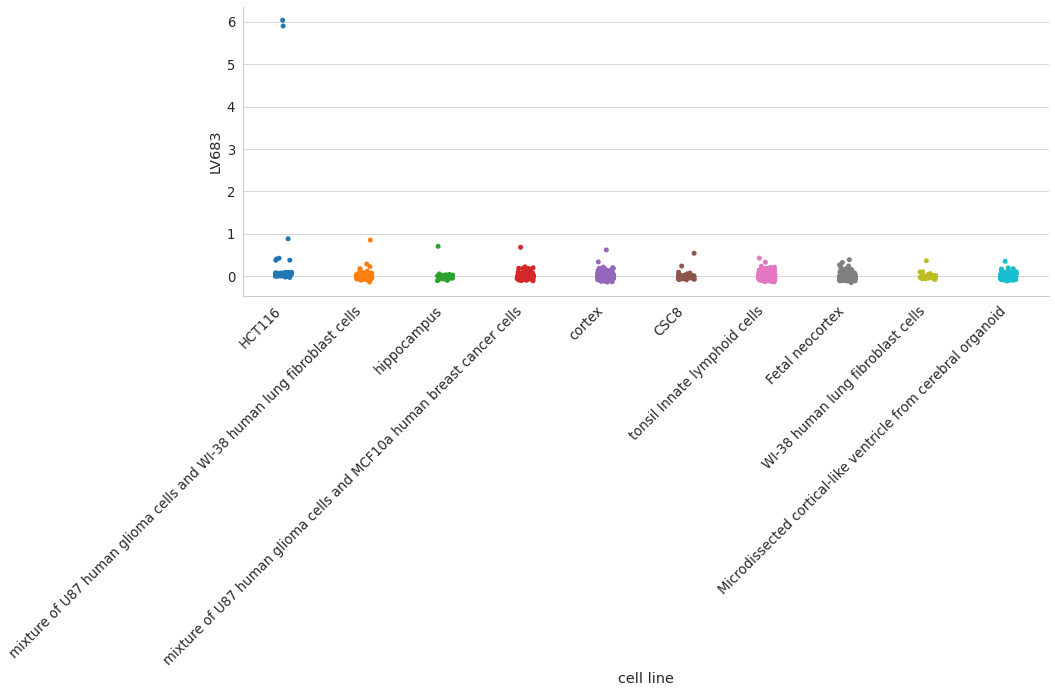

In [38]:
with sns.plotting_context("paper", font_scale=1.5), sns.axes_style("whitegrid"):
    sns.catplot(
        data=final_plot_data,
        y=LV_NAME,
        x=SELECTED_ATTRIBUTES[0],
        order=attr_order,
        kind="strip",
        height=5,
        aspect=3,
    )
    plt.xticks(rotation=45, horizontalalignment="right")

    # You can save the figure if you uncomment the code below
    # the figure will be created under ${DATA_FOLDER}/results/demo

    plt.savefig(
        OUTPUT_CELL_TYPE_FILEPATH,
        bbox_inches="tight",
        facecolor="white",
    )

# Debug

Now that you have the figure for your LV, you can debug some things.
For example, you'll see above that some samples are "NOT CATEGORIZED".
Let's see which are those:

In [38]:
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None
):
    _tmp = final_plot_data[
        final_plot_data[SELECTED_ATTRIBUTES[0]].str.contains("Mesenc")
    ]
    display(_tmp.head(20))

cell type     LV582
project   run                                        
SRP012461 SRR490308  Mesenchymal Stem Cells  0.431175
          SRR490311  Mesenchymal Stem Cells  0.109218
          SRR490229  Mesenchymal Stem Cells  0.106094
          SRR490280  Mesenchymal Stem Cells  0.060764
          SRR490231  Mesenchymal Stem Cells  0.055113
          SRR490226  Mesenchymal Stem Cells  0.047083
          SRR490245  Mesenchymal Stem Cells  0.038019
          SRR490327  Mesenchymal Stem Cells  0.035258
          SRR490305  Mesenchymal Stem Cells  0.033120
          SRR490338  Mesenchymal Stem Cells  0.032719
          SRR490336  Mesenchymal Stem Cells  0.031067
          SRR490337  Mesenchymal Stem Cells  0.030776
          SRR490284  Mesenchymal Stem Cells  0.030576
          SRR490331  Mesenchymal Stem Cells  0.030554
          SRR490339  Mesenchymal Stem Cells  0.028162
          SRR490333  Mesenchymal Stem Cells  0.027978
          SRR490220  Mesenchymal Stem Cells  0.027498
          SRR490296  Mesenchymal Stem Cells  0.027087
          SRR490328  Mesenchymal Stem Cells  0.027043
          SRR490290  Mesenchymal Stem Cells  0.026657

We don't have information about cell type/tissue for these.
But we can manually go to the URL showed before and check out.
For example, for `SRP015360` we can open our browser with this URL:
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP012461, and see that the samples were taken from neutrophils.

If you need to see which information is provided by each SRP, you can again use the code below:

In [39]:
# what is there in these projects?
lv_data.loc[["SRP012461"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(60)

cell type       treatment day  \
project   run                                                     
SRP012461 SRR490465             Fibroblasts    Osteogenesis  d3   
          SRR490467             Fibroblasts    Osteogenesis  d3   
          SRR490464             Fibroblasts    Osteogenesis  d3   
          SRR490466             Fibroblasts    Osteogenesis  d3   
          SRR490308  Mesenchymal Stem Cells      Noninduced  d0   
          SRR490311  Mesenchymal Stem Cells      Noninduced  d0   
          SRR490229  Mesenchymal Stem Cells    Adipogenesis  d3   
          SRR490280  Mesenchymal Stem Cells    Osteogenesis  d1   
          SRR490231  Mesenchymal Stem Cells    Adipogenesis  d3   
          SRR490425             Fibroblasts    Adipogenesis  d7   
          SRR490456             Fibroblasts      Noninduced  d0   
          SRR490226  Mesenchymal Stem Cells    Adipogenesis  d2   
          SRR490449             Fibroblasts    Adipogenesis  d5   
          SRR490459             Fibroblasts      Noninduced  d0   
          SRR490452             Fibroblasts    Adipogenesis  d7   
          SRR490458             Fibroblasts      Noninduced  d0   
          SRR490514             Fibroblasts    Osteogenesis  d7   
          SRR490446             Fibroblasts    Adipogenesis  d4   
          SRR490571             Fibroblasts  Chondrogenesis  d5   
          SRR490511             Fibroblasts    Osteogenesis  d6   
          SRR490522             Fibroblasts  Chondrogenesis  d1   
          SRR490512             Fibroblasts    Osteogenesis  d7   
          SRR490427             Fibroblasts    Adipogenesis  d7   
          SRR490523             Fibroblasts  Chondrogenesis  d1   
          SRR490421             Fibroblasts    Adipogenesis  d6   
          SRR490517             Fibroblasts      Noninduced  d0   
          SRR490429             Fibroblasts      Noninduced  d0   
          SRR490509             Fibroblasts    Osteogenesis  d6   
          SRR490245  Mesenchymal Stem Cells      Noninduced  d0   
          SRR490510             Fibroblasts    Osteogenesis  d6   
          SRR490445             Fibroblasts    Adipogenesis  d4   
          SRR490444             Fibroblasts    Adipogenesis  d4   
          SRR490327  Mesenchymal Stem Cells    Osteogenesis  d4   
          SRR490515             Fibroblasts    Osteogenesis  d7   
          SRR490447             Fibroblasts    Adipogenesis  d4   
          SRR490520             Fibroblasts  Chondrogenesis  d1   
          SRR490428             Fibroblasts      Noninduced  d0   
          SRR490418             Fibroblasts    Adipogenesis  d5   
          SRR490305  Mesenchymal Stem Cells    Osteogenesis  d7   
          SRR490419             Fibroblasts    Adipogenesis  d5   
          SRR490485             Fibroblasts      Noninduced  d0   
          SRR490338  Mesenchymal Stem Cells    Osteogenesis  d7   
          SRR490513             Fibroblasts    Osteogenesis  d7   
          SRR490499             Fibroblasts    Osteogenesis  d3   
          SRR490541             Fibroblasts  Chondrogenesis  d6   
          SRR490491             Fibroblasts    Osteogenesis  d1   
          SRR490497             Fibroblasts    Osteogenesis  d3   
          SRR490336  Mesenchymal Stem Cells    Osteogenesis  d7   
          SRR490508             Fibroblasts    Osteogenesis  d6   
          SRR490337  Mesenchymal Stem Cells    Osteogenesis  d7   
          SRR490519             Fibroblasts      Noninduced  d0   
          SRR490524             Fibroblasts  Chondrogenesis  d2   
          SRR490284  Mesenchymal Stem Cells    Osteogenesis  d2   
          SRR490457             Fibroblasts      Noninduced  d0   
          SRR490331  Mesenchymal Stem Cells    Osteogenesis  d5   
          SRR490516             Fibroblasts      Noninduced  d0   
          SRR490417             Fibroblasts    Adipogenesis  d5   
          SRR490498             Fibroblasts    Osteogenesis  d3   
          SRR4

Now you can go back to section `Standardize cell type names` in this notebook and adjust according to this findings to improve the figure.
Once you are happy, you can remove the `NOT CATEGORIZED` items by uncommenting the code in `Delete samples with no tissue/cell type information`.